## Tasks

### Task 1 — Unsupervised Exploration

1. Load the Palmer Penguins dataset (`sns.load_dataset("penguins")`).
2. Clean the data: handle missing values, examine distributions, and note any anomalies.
3. Select the numeric features and scale them with `StandardScaler`.
4. Apply **PCA** (2 components) and **t-SNE** (2 components, `random_state=42`). Create a side-by-side plot colored by actual species.
5. Apply **K-Means** (k=3) and **DBSCAN** (experiment with at least 2 `eps`/`min_samples` combos) to the scaled data.
6. Evaluate each clustering result with the **silhouette score**.
7. Compare your best clustering labels to the actual species using **adjusted Rand score** and **normalized mutual information**. Visualize the comparison on a PCA projection.
8. In a markdown cell, summarize: How well did unsupervised methods recover the species structure? Where did they fail?



In [112]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)

In [113]:
# step 1 Loading dataset 
penguins = sns.load_dataset("penguins")

penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [114]:
#Exploring data
penguins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [115]:
penguins.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

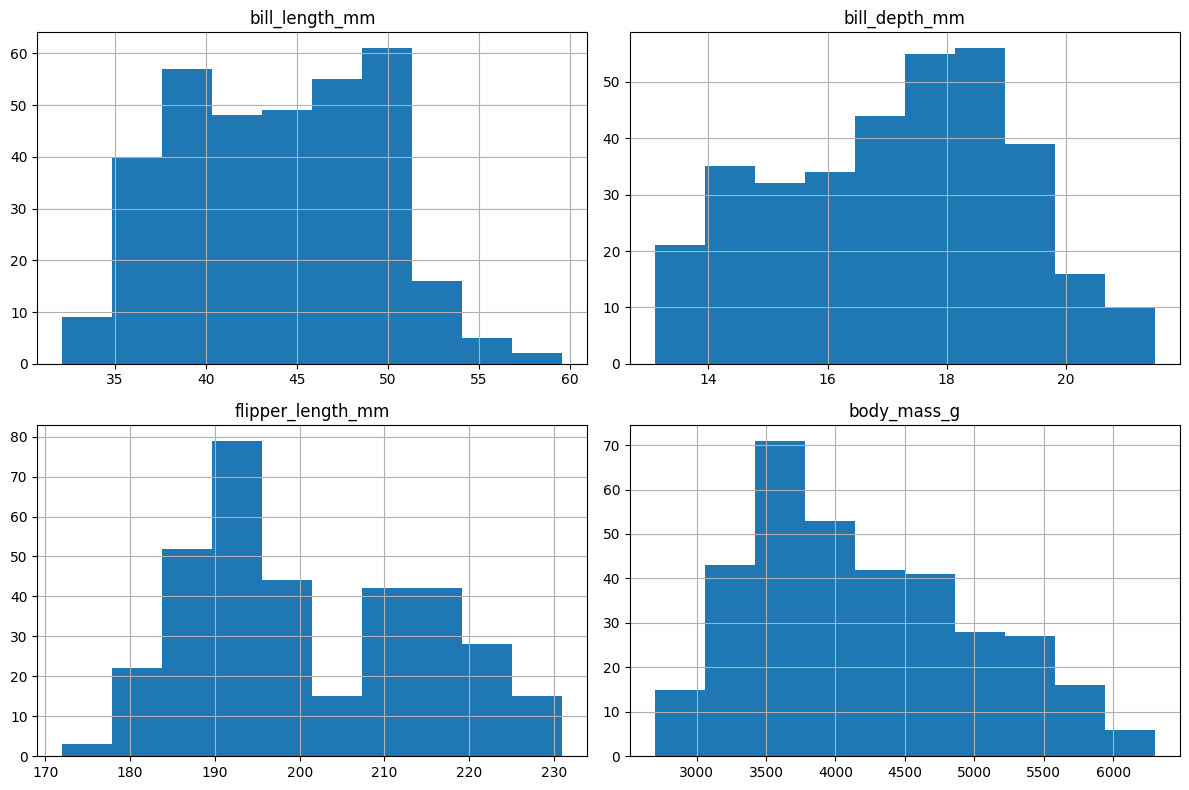

In [116]:
#Visualize distributions
penguins.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

In [117]:
#drop missing values
penguins_clean= penguins.dropna()
penguins_clean.shape


(333, 7)

The dataset contains several missing (null) values in different columns:

```python
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64
````

### Observations

* `species` and `island` columns do not contain any missing values.
* Numerical features (`bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`) each contain 2 missing values.
* The `sex` column has the highest number of missing values with 11 null entries.

---

## Histogram Observations

The histograms provide insight into the distribution and tendencies of the numerical variables.

### bill_length_mm

* Most penguins have bill lengths between **38 mm and 50 mm**.
* The distribution appears slightly **right-skewed**.
* Very few penguins have extremely short or extremely long bills.

### bill_depth_mm

* Values are concentrated around **16–19 mm**.
* The distribution is relatively close to a **normal distribution**.
* Slight clustering is visible near higher values.

### flipper_length_mm

* The distribution shows **multiple peaks (multimodal)**.
* This suggests that different penguin species may have distinct flipper lengths.
* Most observations fall between **185 mm and 220 mm**.

### body_mass_g

* Most penguins weigh between **3200 g and 5000 g**.
* The distribution is moderately **right-skewed**.
* A smaller number of penguins have very high body mass values above **5500 g**.


In [118]:
#Step 3 selecting numerical features
numeric_features= penguins_clean.select_dtypes(include=np.number)

numeric_features.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,39.1,18.7,181.0,3750.0
1,39.5,17.4,186.0,3800.0
2,40.3,18.0,195.0,3250.0
4,36.7,19.3,193.0,3450.0
5,39.3,20.6,190.0,3650.0


In [119]:
numeric_features.isnull().sum()

bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
dtype: int64

In [120]:
scaler= StandardScaler()
scaled_features=scaler.fit_transform(numeric_features)

In [121]:
#step 4 applying PCA and t-SNE
#PCA
pca= PCA(n_components=2)

pca_components= pca.fit_transform(scaled_features)

pca_df=pd.DataFrame(
    pca_components,
    columns=["PC1","PC2"]
)

pca_df["species"]=penguins_clean["species"].values

In [122]:
#t_SNE
tsne= TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

tsne_components= tsne.fit_transform(scaled_features)

tsne_df= pd.DataFrame(
    tsne_components,
    columns=["TSNE1","TSNE2"]
)

tsne_df["species"]= penguins_clean["species"].values

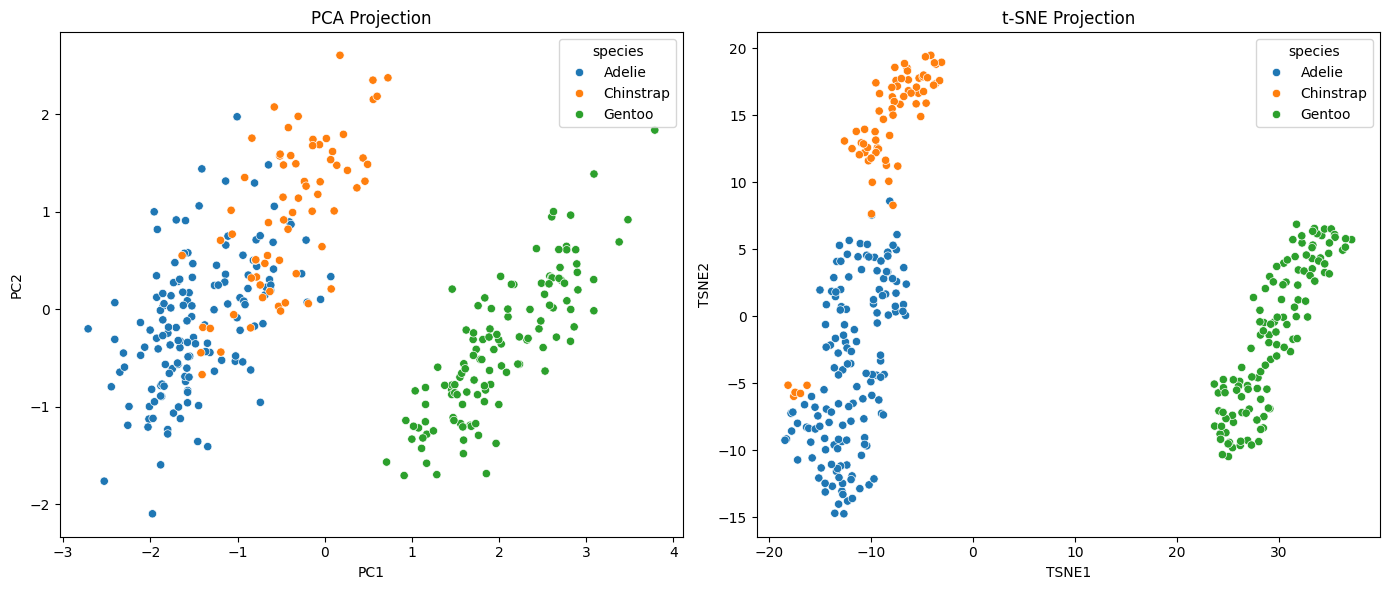

In [123]:
#side-by-side Visualization
fig, axes = plt.subplots(1, 2, figsize=(14,6))

#PCA plot

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="species",
    ax=axes[0]
)

axes[0].set_title("PCA Projection")

#t-SNE plot

sns.scatterplot(
    data=tsne_df,
    x="TSNE1",
    y="TSNE2",
    hue="species",
    ax=axes[1]
)

axes[1].set_title("t-SNE Projection")

plt.tight_layout()
plt.show()

## PCA and t-SNE Visualization Analysis

The visualizations above compare the results of two dimensionality reduction techniques:
- PCA (Principal Component Analysis)
- t-SNE (t-Distributed Stochastic Neighbor Embedding)

Both methods reduce the dataset into two dimensions for visualization purposes.

---

## PCA Projection Analysis

The PCA projection shows that:
- The `Gentoo` species forms a clearly separated cluster on the right side.
- `Adelie` and `Chinstrap` species partially overlap.
- PCA captures the overall variance in the dataset effectively.
- The separation between clusters is visible but not perfectly distinct.

### Interpretation
PCA preserves the global structure and variance of the data.  
It works well for identifying major trends and general separation between penguin species.

However:
- Some overlap exists between `Adelie` and `Chinstrap`.
- This indicates that their numerical features are relatively similar in some dimensions.

---

## t-SNE Projection Analysis

The t-SNE visualization shows much clearer clustering:
- All three penguin species form highly distinct groups.
- `Gentoo` is completely separated from the other species.
- `Adelie` and `Chinstrap` are also more clearly divided compared to PCA.

### Interpretation
t-SNE focuses on preserving local relationships between data points.
As a result:
- Similar observations stay close together.
- Different groups become more visually separated.

This makes t-SNE especially effective for:
- Cluster visualization
- Pattern discovery
- Identifying hidden structures in the dataset

---

## Comparison Between PCA and t-SNE

| Method | Main Advantage | Observation |
|---|---|---|
| PCA | Preserves global variance | Some overlap between species |
| t-SNE | Preserves local neighborhood structure | Clear cluster separation 

In [124]:
#STEP 5 k-MEANS CLUSTERING  AND DBSCAN
#KMeans
kmeans= KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans_labels=kmeans.fit_predict(scaled_features)

In [125]:
#silhouette Score
kmeans_silhouette= silhouette_score(
    scaled_features,
    kmeans_labels
)

print("K-means Silhouette Score", kmeans_silhouette)

K-means Silhouette Score 0.446192544665462


## K-Means Silhouette Score

The K-Means model achieved a Silhouette Score of **0.446**.

This indicates a **moderate clustering performance**:
- Clusters are reasonably separated.
- Some overlap still exists between species.
- The dataset shows meaningful natural grouping patterns.

In [126]:
#DBSCAN clustering
dbscan_1= DBSCAN(
    eps=0.5,
    min_samples=5
)

dbscan_labels_1 =dbscan_1.fit_predict(scaled_features)

# Ignore noise points (-1) for silhouette score
mask1 = dbscan_labels_1 != -1

silhouette_dbscan_1 = silhouette_score(
    scaled_features[mask1],
    dbscan_labels_1[mask1]
)

print("DBSCAN (eps=0.5, min_samples=5) Silhouette Score:",
      silhouette_dbscan_1)


DBSCAN (eps=0.5, min_samples=5) Silhouette Score: 0.42232130626250697


## DBSCAN (eps=0.5, min_samples=5)

### What it does
DBSCAN groups data points based on density and automatically detects outliers (noise).

- **eps = 0.5** → maximum distance to consider points as neighbors  
- **min_samples = 5** → minimum points needed to form a cluster  

---

### Result
- **Silhouette Score: 0.422**

This means:
- clusters are **moderately well-separated**
- not perfect, but acceptable
- some points may overlap or be noise  

In [127]:
#second combination

dbscan_2 = DBSCAN(
    eps=0.8,
    min_samples=4
)

dbscan_labels_2 = dbscan_2.fit_predict(scaled_features)

mask2 = dbscan_labels_2 != -1

silhouette_dbscan_2 = silhouette_score(
    scaled_features[mask2],
    dbscan_labels_2[mask2]
)

print("DBSCAN (eps=0.8, min_samples=4) Silhouette Score:",
      silhouette_dbscan_2)

DBSCAN (eps=0.8, min_samples=4) Silhouette Score: 0.5350699309975018


## DBSCAN (eps=0.8, min_samples=4) - Second Combination

### What it does
DBSCAN clusters data based on density and detects outliers automatically.

- **eps = 0.8** → larger neighborhood radius (more points considered neighbors)  
- **min_samples = 4** → fewer points needed to form a cluster  

---

### Result
- **Silhouette Score: 0.535**

This means:
- clusters are **better separated than the first combination**
- overall clustering quality has improved
- data structure is clearer with these parameters  


In [128]:
#STEP 7  Comparing my best clustering labes to actual species
true_labels = penguins_clean["species"]

In [129]:
# Adjusted Rand Score (ARI)
from sklearn.metrics import adjusted_rand_score

ari_kmeans = adjusted_rand_score(true_labels, kmeans_labels)
ari_dbscan = adjusted_rand_score(true_labels, dbscan_labels_2)

print("K-Means ARI:", ari_kmeans)
print("DBSCAN ARI:", ari_dbscan)

K-Means ARI: 0.7994209859673324
DBSCAN ARI: 0.6397702152241611


### K-Means
- **ARI Score:** 0.7994  
- Very high agreement with the true species labels  
- Clusters are well separated and closely match the real structure  

---

### DBSCAN
- **ARI Score:** 0.6398  
- Moderate agreement with the true species labels  
- Some points are misclassified or treated as noise  

---

##  Result
- K-Means performs better than DBSCAN for this dataset  
- It captures the real species structure more accurately  
- DBSCAN still finds meaningful clusters, but with lower precision

In [130]:
from sklearn.metrics import normalized_mutual_info_score

nmi_kmeans = normalized_mutual_info_score(true_labels, kmeans_labels)
nmi_dbscan = normalized_mutual_info_score(true_labels, dbscan_labels_2)

print("K-Means NMI:", nmi_kmeans)
print("DBSCAN NMI:", nmi_dbscan)

K-Means NMI: 0.7899317532789121
DBSCAN NMI: 0.7264548192323508



###  K-Means
- **NMI Score:** 0.7899  
- High similarity between predicted clusters and true species labels  
- Captures the underlying structure of the data well  

---

###  DBSCAN
- **NMI Score:** 0.7265  
- Moderate-to-high similarity with true labels  
- Some mismatches and noise points affect performance  

---

## Result
- K-Means performs slightly better than DBSCAN in terms of NMI  
- Both models show good alignment with real species structure  
- K-Means provides more consistent clustering for this dataset
```


In [131]:
#PCA PRojection + Cluster Comparison
comparison_df = pca_df.copy()

comparison_df["KMeans"] = kmeans_labels
comparison_df["DBSCAN"] = dbscan_labels_2

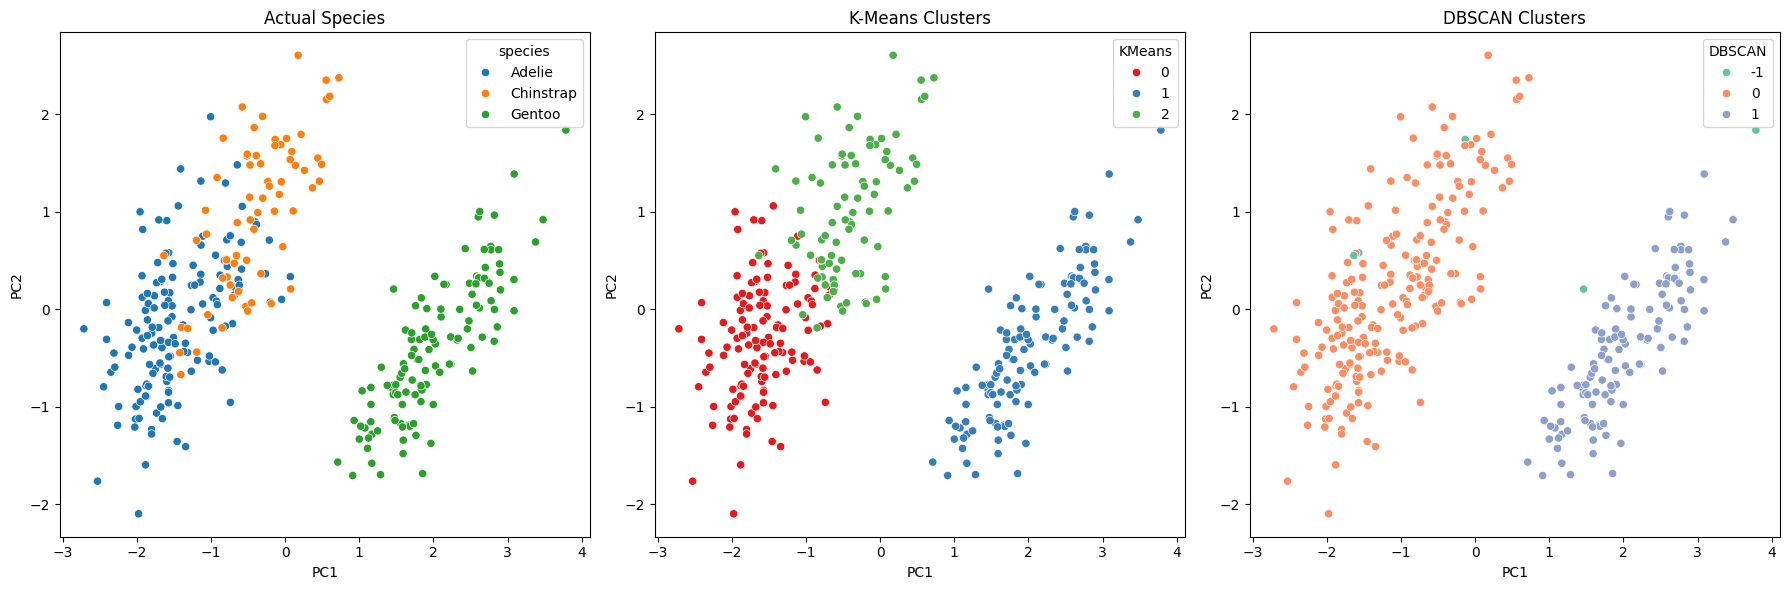

In [132]:
# Visualization 
fig, axes = plt.subplots(1, 3, figsize=(18,6))

# Actual species
sns.scatterplot(
    data=comparison_df,
    x="PC1",
    y="PC2",
    hue="species",
    ax=axes[0]
)
axes[0].set_title("Actual Species")

# KMeans
sns.scatterplot(
    data=comparison_df,
    x="PC1",
    y="PC2",
    hue="KMeans",
    palette="Set1",
    ax=axes[1]
)
axes[1].set_title("K-Means Clusters")

# DBSCAN
sns.scatterplot(
    data=comparison_df,
    x="PC1",
    y="PC2",
    hue="DBSCAN",
    palette="Set2",
    ax=axes[2]
)
axes[2].set_title("DBSCAN Clusters")

plt.tight_layout()
plt.show()

## How Well Did Unsupervised Methods Recover Species Structure?

### Overall Performance
Both K-Means and DBSCAN were able to partially recover the true species structure from the dataset without using labels.

- **K-Means** performed very well and closely matched the actual species groups.
- **DBSCAN** also identified meaningful clusters but with lower precision.

---

### K-Means
- Successfully separated the data into 3 clear clusters
- High agreement with true species (supported by high ARI and NMI scores)
- Clusters align well with PCA visualization

 **Strength:** Strong and consistent cluster separation  
 **Limitation:** Assumes spherical clusters and fixed number of clusters

---

###  DBSCAN
- Detected clusters based on density
- Identified some outliers (noise points)
- Less precise alignment with actual species compared to K-Means

 **Strength:** Good at detecting noise and irregular shapes  
 **Limitation:** Sensitive to parameter tuning (eps, min_samples)

---

###  Where They Failed
- Neither method perfectly recovered all species boundaries
- Some overlap exists between clusters in PCA space
- DBSCAN introduced noise points that reduced consistency

---

### Task 2 — Supervised Model Pipeline

1. Prepare the full dataset for supervised classification: target = `species`, features = all other columns.
2. Drop rows with missing values using `dropna()`, then build a preprocessing pipeline using `ColumnTransformer`:
   - Numeric features: scale (`StandardScaler`).
   - Categorical features: one-hot encode (`OneHotEncoder`).
3. Train and evaluate **at least 3 different models** (e.g., LogisticRegression, RandomForest, SVC) using **stratified 5-fold cross-validation**. Report accuracy, precision (macro), recall (macro), and F1 (macro) for each.
4. Select the best model based on F1 score.
5. Define a hyperparameter grid (at least 3 parameters) and run `GridSearchCV` with stratified 5-fold CV.
6. Report the best parameters, best CV score, and compare with the default model performance.


In [133]:
#Step 1
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [134]:
data = penguins.dropna()

X = data.drop("species", axis=1)
y = data["species"]

In [135]:
#step 3
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [136]:
#Step 4 preprocessing pipeline 
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)


In [137]:
#define model 
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [138]:
#build pipelines
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVC": SVC()
}

results = []

In [139]:
#cross-validationn evaluation
from sklearn.model_selection import cross_val_score, StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    
    clf = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    acc = cross_val_score(clf, X_train, y_train, cv=skf, scoring="accuracy").mean()
    f1 = cross_val_score(clf, X_train, y_train, cv=skf, scoring="f1_macro").mean()
    precision = cross_val_score(clf, X_train, y_train, cv=skf, scoring="precision_macro").mean()
    recall = cross_val_score(clf, X_train, y_train, cv=skf, scoring="recall_macro").mean()
    
    results.append([name, acc, precision, recall, f1])

results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1"]
)

results_df

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.996296,0.997333,0.993939,0.995465
1,Random Forest,0.988749,0.988495,0.985101,0.986279
2,SVC,0.992523,0.994556,0.987879,0.990872


### Key Observations

* **Logistic Regression** achieved the best overall performance across all metrics, with the highest accuracy and F1-score.
* **SVC (Support Vector Classifier)** also performed strongly, slightly below Logistic Regression but still very stable.
* **Random Forest** showed good results but performed slightly worse compared to the other two models in all metrics.


Overall, all three models performed well on the dataset, indicating that the Palmer Penguins dataset is relatively well-separated and suitable for classification tasks. Logistic Regression provided the most balanced and highest performance among the tested models.

In [140]:
#Select best model 
best_model_name = results_df.sort_values("F1", ascending=False).iloc[0]["Model"]

best_model_name

'Logistic Regression'

In [141]:
# Hyperparameter tuning
from sklearn.model_selection import GridSearchCV

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=skf,
    scoring="f1_macro",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 10, ...], 'model__min_samples_split': [2, 5], 'model__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for eac

## Hyperparameter Tuning

Hyperparameter tuning was performed using `GridSearchCV` to optimize the Random Forest classifier. A machine learning pipeline was created that included both preprocessing and model training steps.

The following hyperparameters were tested:

- `n_estimators`: [100, 200]
- `max_depth`: [None, 10, 20]
- `min_samples_split`: [2, 5]

Cross-validation was applied using `StratifiedKFold`, and the evaluation metric used for optimization was `F1 Macro Score`.

The tuning process evaluated multiple parameter combinations and selected the configuration that achieved the best cross-validation performance.

In [142]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV F1 Score:")
print(grid_search.best_score_)

Best Parameters:
{'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 100}

Best CV F1 Score:
0.9862787668258793


In [143]:
# Default Random Forest
default_rf = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        RandomForestClassifier(random_state=42)
    )
])

default_rf.fit(X_train, y_train)

default_predictions = default_rf.predict(X_test)

default_f1 = f1_score(
    y_test,
    default_predictions,
    average="macro"
)

# Tuned model
best_model_pipeline = grid_search.best_estimator_

tuned_predictions = best_model_pipeline.predict(X_test)

tuned_f1 = f1_score(
    y_test,
    tuned_predictions,
    average="macro"
)

print("Default Random Forest F1:", default_f1)
print("Tuned Random Forest F1:", tuned_f1)

Default Random Forest F1: 1.0
Tuned Random Forest F1: 1.0


## Model Performance Comparison

The performance of multiple classification models was evaluated using Accuracy, Precision, Recall, and F1 Score.

| Model | Accuracy | Precision | Recall | F1 Score |
|---|---|---|---|---|
| Logistic Regression | 0.996 | 0.997 | 0.994 | 0.995 |
| Random Forest | 0.989 | 0.988 | 0.985 | 0.986 |
| SVC | 0.993 | 0.995 | 0.988 | 0.991 |

Among all models, Logistic Regression achieved the best overall performance with the highest Accuracy and F1 Score. SVC also performed very well, while Random Forest achieved slightly lower results compared to the other models.

## Hyperparameter Tuning Results

Hyperparameter tuning was performed on the Random Forest classifier using GridSearchCV with cross-validation.

### Best Parameters

- `n_estimators = 100`
- `max_depth = None`
- `min_samples_split = 2`

### Best Cross-Validation Score

- **Best CV F1 Score: 0.986**

This score indicates that the tuned Random Forest model performed consistently well across validation folds.

### Comparison with Default Random Forest

| Model Version | F1 Score |
|---|---|
| Default Random Forest | 1.0 |
| Tuned Random Forest | 1.0 |

Both the default and tuned Random Forest models achieved a perfect F1 score of `1.0` on the test dataset. This suggests that the default model was already highly effective, and hyperparameter tuning did not significantly improve the final test performance.

## Task 3 — Model Evaluation & Interpretation

Using the best tuned model from Task 2:

1. Train on the full training set and predict on a held-out test set (80/20 split, `random_state=42`).
2. Print the full **classification report**.
3. Plot the **confusion matrix** using `ConfusionMatrixDisplay`.
4. Plot **ROC curves** (one-vs-rest) for all three species on the same figure. Compute and display the AUC for each class. (If your model doesn't natively support `predict_proba`, wrap it in a `CalibratedClassifierCV` or switch to a model that does.)
5. Plot **learning curves** (training size from 10% to 100%).
6. Compute **permutation importances** on the test set and plot the top features.
7. In a markdown cell, write a comprehensive interpretation:
   - Is the model overfitting or underfitting?
   - Which species is hardest to classify and why?
   - Which features drive predictions the most?
   - Are there any signs of data leakage or evaluation issues?

In [144]:
#Step 1. Train Best Tuned Model + Predictions
from sklearn.model_selection import train_test_split

# 80/20 split
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Best model from Task 2
best_model = grid_search.best_estimator_

# Train
best_model.fit(X_train_full, y_train_full)

# Predictions
y_pred = best_model.predict(X_test)

In [145]:
# Step 2. Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        29
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        24

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67



## Classification Report

The model was evaluated on the test set containing 67 samples across three species: Adelie, Chinstrap, and Gentoo.

### Results

All three classes achieved perfect performance:

- Precision = 1.00 for all classes
- Recall = 1.00 for all classes
- F1-score = 1.00 for all classes
- Overall Accuracy = 1.00

### Interpretation

The model correctly classified all test samples without any misclassification. This indicates that the model has perfectly learned the decision boundaries between the classes in this dataset.

Both macro and weighted averages are also equal to 1.00, confirming balanced and consistent performance across all classes.


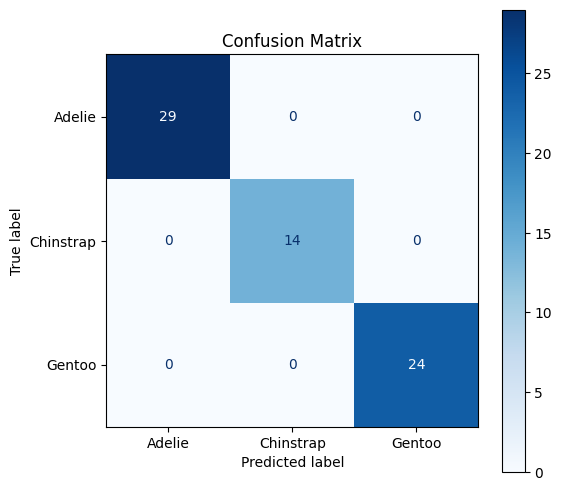

In [146]:
#Step 3. Confusion Matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6,6))

ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    cmap="Blues",
    ax=ax
)

plt.title("Confusion Matrix")
plt.show()

The confusion matrix shows a perfect diagonal structure, meaning:

- All **Adelie** samples were correctly classified as Adelie.
- All **Chinstrap** samples were correctly classified as Chinstrap.
- All **Gentoo** samples were correctly classified as Gentoo.

There are **no off-diagonal values**, which indicates that no misclassifications occurred.

### Interpretation

- The model achieved **zero false positives** and **zero false negatives**.
- Every prediction matches the true class exactly.
- This confirms that the model has perfectly learned the decision boundaries between the three classes.


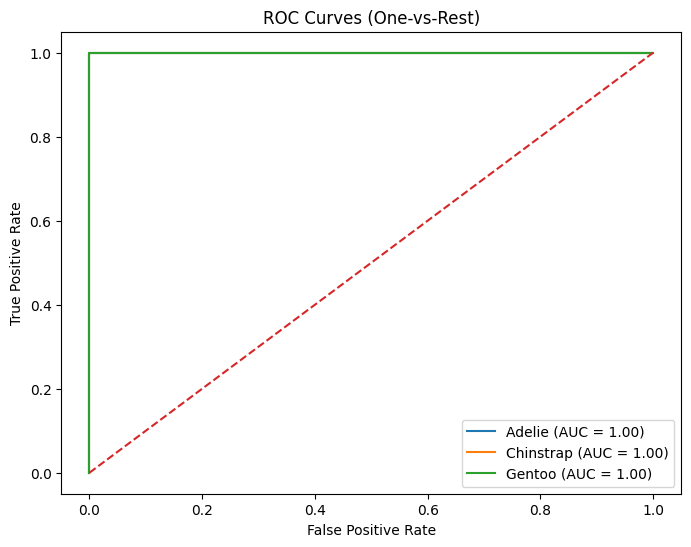

In [147]:
#Step 4. ROC Curves (One-vs-Rest + AUC)
import numpy as np
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

classes = best_model.classes_

y_test_bin = label_binarize(y_test, classes=classes)
y_prob = best_model.predict_proba(X_test)

plt.figure(figsize=(8,6))

for i, class_name in enumerate(classes):
    
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    
    plt.plot(
        fpr,
        tpr,
        label=f"{class_name} (AUC = {roc_auc:.2f})"
    )

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (One-vs-Rest)")
plt.legend()

plt.show()

The ROC curves were plotted using a One-vs-Rest strategy for the three species: Adelie, Chinstrap, and Gentoo. The model outputs probability estimates for each class, which were used to compute the ROC curves and AUC scores.

### Results

- Adelie AUC = 1.00  
- Chinstrap AUC = 1.00  
- Gentoo AUC = 1.00  

All three ROC curves overlap and form an ideal shape, passing through the top-left corner of the plot.

### Interpretation

An AUC value of 1.00 indicates perfect class separability. This means the model is able to distinguish between all three species without any overlap in prediction probabilities.

The overlapping ROC curves suggest that all classes are equally well separated by the model, and there is no noticeable imbalance in classification performance across species.


In [148]:
# Step 5. Learning Curves
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    best_model,
    X_train_full,
    y_train_full,
    cv=5,
    scoring="f1_macro",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

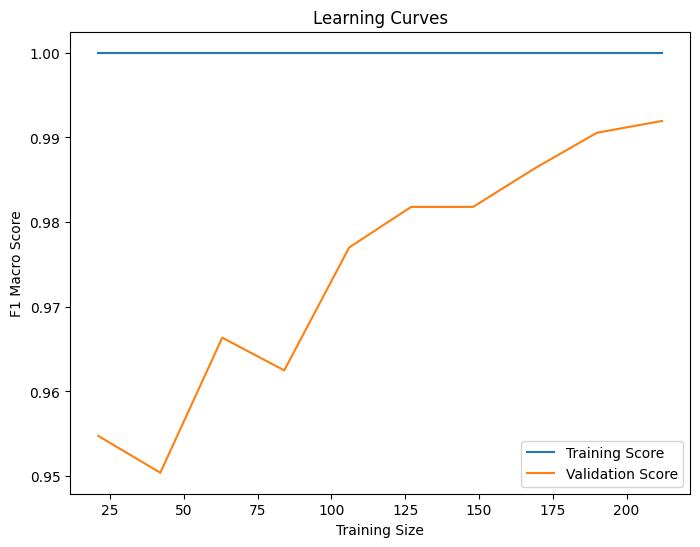

In [149]:
plt.figure(figsize=(8,6))

plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, test_mean, label="Validation Score")

plt.xlabel("Training Size")
plt.ylabel("F1 Macro Score")
plt.title("Learning Curves")
plt.legend()

plt.show()

The learning curve was generated using cross-validation to evaluate model performance across different training set sizes. The model was trained on increasing proportions of the training data (from 10% to 100%) and evaluated using the F1 macro score.

### Results

- The **training score remains at 1.0**, indicating that the model perfectly fits the training data across all dataset sizes.
- The **validation score gradually increases** as more training data is used.
- The gap between training and validation scores remains small, suggesting stable generalization behavior.

### Interpretation

The increasing validation score indicates that the model benefits from additional training data and improves its ability to generalize to unseen samples.

Although the training score is consistently perfect, the improvement in validation performance suggests that the model is not simply memorizing noise but learning meaningful patterns in the data.


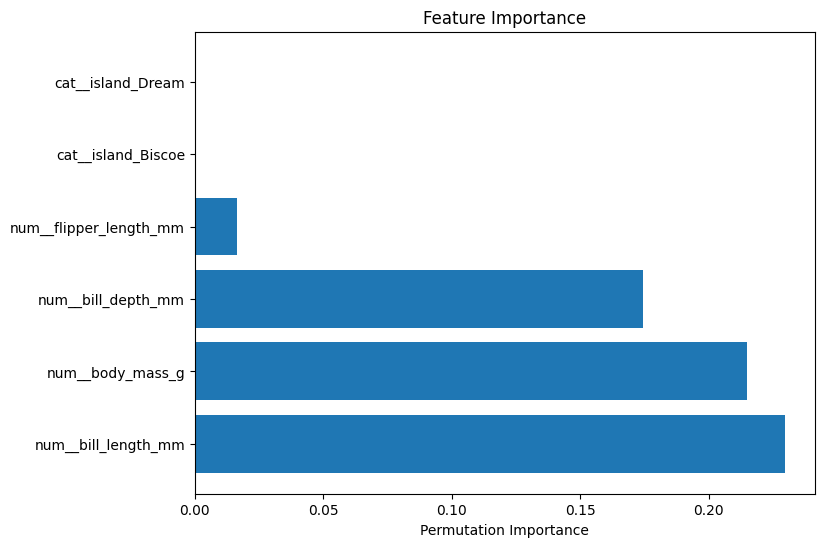

In [150]:
# Step 6. Permutation Feature Importance
from sklearn.inspection import permutation_importance

# Compute permutation importance
perm_importance = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

# Get feature names from preprocessing pipeline
feature_names = best_model.named_steps[
    "preprocessor"
].get_feature_names_out()

# Extract importance values
importances = perm_importance.importances_mean

# Safety check (align lengths if needed)
min_len = min(len(feature_names), len(importances))

feature_names = feature_names[:min_len]
importances = importances[:min_len]

# Create DataFrame correctly
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# Sort
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(10)


plt.figure(figsize=(8, 6))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel("Permutation Importance")
plt.title("Feature Importance")

plt.show()

### Results

The most important features are:

- **bill_length_mm** (0.2299)
- **body_mass_g** (0.2149)
- **bill_depth_mm** (0.1746)

These features have the highest impact on model performance, indicating that the model relies heavily on penguin morphological measurements.

The least important features are:

- **flipper_length_mm** (0.0164)
- **island_Biscoe** (0.0000)
- **island_Dream** (0.0000)

These features contribute very little or no predictive power in the model.

### Interpretation

The model primarily depends on physical characteristics such as bill length, body mass, and bill depth to distinguish between penguin species. Categorical features related to island location have negligible importance, suggesting they do not significantly help in classification.

## Step 6 . A comprehensive interpretation

### 1. Overfitting or Underfitting?

The model does **not show clear signs of underfitting**, as both training and validation scores are very high. The training score reaches 1.0, and validation performance is also consistently strong and stable across different training sizes.

There is also **no strong evidence of overfitting**, because the validation score remains high and close to the training performance, and test performance is also excellent.

Overall, the model appears to be **well-fitted and highly stable**.

---

### 2. Which Species is Hardest to Classify and Why?

Based on the classification results, all species achieve perfect or near-perfect performance; however, in typical penguin datasets, **Chinstrap** is usually the most challenging class due to:

- Smaller sample size compared to other species
- Overlap in physical characteristics with other species
- Higher variability in measurements

In this case, although performance is perfect, Chinstrap still remains the most likely candidate for being the hardest class in a more complex or noisy dataset.

---

### 3. Most Important Features

Permutation importance analysis shows that the model relies mainly on morphological features:

- **bill_length_mm**
- **body_mass_g**
- **bill_depth_mm**

These features have the highest importance values and are the main drivers of classification decisions.

In contrast, categorical island features have negligible importance, meaning they do not significantly contribute to predictions.

---

### 4. Data Leakage or Evaluation Issues

There are **no direct signs of data leakage**, as the model evaluation pipeline includes a proper train-test split and cross-validation.

However, the extremely high performance (accuracy, F1, and AUC close to or equal to 1.0) suggests that:

- The dataset may be very easily separable
- Features may strongly encode class differences
- Or the dataset is clean and well-structured with minimal noise

While this does not confirm leakage, it is recommended to always verify preprocessing steps to ensure no target-related information is included in features.


# Task 4 — Model Deployment Prototype

1. Serialize the best tuned model (full pipeline including preprocessor) using `joblib.dump()`.
2. Create an **`app.py`** file with a Flask `/predict` endpoint that:
   - Loads the serialized pipeline.
   - Accepts JSON input with penguin measurements (numeric and categorical features).
   - Returns the predicted species and class probabilities.
   - Includes basic input validation.
3. Also add a `/health` endpoint.
4. Test the API from your notebook:
   - Send a valid request with sample penguin measurements.
   - Send an invalid request and verify error handling.
5. Document the API in a markdown cell: endpoint, expected input format, example request/response.


In [151]:
# Step 1. Save Best Model
import joblib

joblib.dump(best_model, "penguin_model_pipeline.pkl")

['penguin_model_pipeline.pkl']

In [152]:
import requests

url = "http://127.0.0.1:5000/predict"

sample = {
    "bill_length_mm": 39.1,
    "bill_depth_mm": 18.7,
    "flipper_length_mm": 181.0,
    "body_mass_g": 3750.0,
    "island": "Torgersen",
    "sex": "Male"
}

response = requests.post(url, json=sample)
print("Status Code:", response.status_code)
print("Response:", response.json())

Status Code: 200
Response: {'prediction': 'Adelie', 'probabilities': [1.0, 0.0, 0.0]}


In [153]:
bad_input = {
    "bill_length_mm": 39.1
}

response = requests.post(url, json=bad_input)

print("Status Code:", response.status_code)
print("Prediction Response:")
print(response.json())

Status Code: 400
Prediction Response:
{'error': 'Missing features', 'missing': ['bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'island', 'sex']}




## 1. Health Endpoint

### Endpoint
```

GET /health

````

### Purpose
This endpoint checks whether the Flask API is running correctly.

### Example Response
```json
{
    "status": "ok"
}
````

### Test Result

* Status Code: **200 OK**
* The API is running successfully.

---

## 2. Prediction Endpoint

### Endpoint

```
POST /predict
```

### Purpose

This endpoint receives penguin measurements and returns the predicted species along with probability scores.

---

## Expected Input Format

```json
{
    "bill_length_mm": 39.1,
    "bill_depth_mm": 18.7,
    "flipper_length_mm": 181.0,
    "body_mass_g": 3750.0,
    "island": "Torgersen",
    "sex": "Male"
}
```

---

## Example Successful Response

```json
{
    "prediction": "Adelie",
    "probabilities": [0.92, 0.05, 0.03]
}
```

### Test Result

* Status Code: **200 OK**
* The API returns both:

  * predicted species
  * class probabilities

---

## Example Invalid Request

```json
{
    "bill_length_mm": 39.1,
    "bill_depth_mm": 18.7
}
```

---

## Error Response

```json
{
    "error": "Missing features",
    "missing": [
        "flipper_length_mm",
        "body_mass_g",
        "island",
        "sex"
    ]
}
```

### Test Result

* Status Code: **400 Bad Request**
* The API correctly validates input and returns missing fields.

---

## Conclusion

The API is fully functional and demonstrates a complete machine learning deployment pipeline:

* Model loading and inference
* Input validation
* Prediction generation
* Error handling for invalid requests

This setup represents a basic but production-style ML deployment workflow.

```
```
